# Probe de geração — completação de genomas virais com EVO2 7B

Terceiro eixo do benchmark: a capacidade **generativa** do `evo2_7b` base em sequência viral. Dois experimentos:

1. **Perplexidade / bits-por-nucleotídeo** — quão bem o modelo *modela* sequência viral (teacher-forced), estratificado por classe/host.
2. **Completação de fragmentos** — quebramos genomas, removemos um trecho, e pedimos ao modelo para **gerar o trecho a partir do contexto a montante**; comparamos o gerado com o real. Mapeia o uso em **metagenômica** (estender contigs virais fragmentados).

> **Leakage (crítico):** o treino do EVO2 (OpenGenome2) **excluiu vírus de eucariotos** e **incluiu bacteriófagos** (Brixton et al., Evo 2, 2025). Logo usamos **vírus de eucariotos como conjunto held-out citável** (garantidamente fora do treino) e, como **comparador "visto no treino"**, uma amostra de **fagos** — o contraste euk×fago mede diretamente o efeito de ter visto ou não a sequência.

*Space SageMaker (L40S 48 GB recomendado), imagem evo2 v2.*

## Pré-requisitos
Iguais aos outros notebooks de probe (imagem evo2 v2, leitura S3 em `corpus/*`, pesos do `evo2_7b`).

In [1]:
# ============================ CONFIG ============================
BUCKET        = "<YOUR_S3_BUCKET>"
MANIFEST_KEY  = "corpus/raw/v1_refseq/composed/composition_manifest.parquet"
FEATURES_KEY  = "corpus/raw/v1_refseq/features/genome_features.parquet"
FASTA_KEY     = "corpus/raw/v1_refseq/fasta/all_genomes.fasta"
LOCAL_DIR     = "/home/<USER>/evo2_probe"

MODEL_NAME    = "evo2_7b"
DEVICE        = "cuda:0"

# Held-out (leakage-safe) e comparador
N_HELDOUT     = 100      # vírus de EUCARIOTOS (fora do treino do EVO2) — conjunto principal
N_SEEN        = 100      # fagos (vistos no treino) — comparador; 0 desliga
PERP_WINDOW   = 8192     # nº de bp para a perplexidade (janela do início do genoma)

# Completação de fragmentos
PROMPT_BP     = 4096     # contexto a montante (o "contig recuperado")
GAP_BP        = 1024     # trecho removido a ser gerado/comparado
TEMPERATURE   = 0.7
TOP_K         = 4        # 4 bases
MARKOV_ORDER  = 4        # baseline de composição
KMER_K        = 4
SEED          = 42

import os; os.makedirs(LOCAL_DIR, exist_ok=True)
print(f"config OK · held-out euk={N_HELDOUT} · comparador fago={N_SEEN} · prompt={PROMPT_BP} gap={GAP_BP}")

config OK · held-out euk=100 · comparador fago=100 · prompt=4096 gap=1024


In [2]:
# ============================ SETUP ============================
import sys, subprocess
def pip(*p): subprocess.run([sys.executable,"-m","pip","install","-q",*p], check=False)
pip("scikit-learn","matplotlib","seaborn","pandas","pyarrow","boto3","tqdm","biopython")
import numpy as np, pandas as pd, torch, random
random.seed(SEED); np.random.seed(SEED)
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    p=torch.cuda.get_device_properties(0); print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 w

torch 2.7.0a0+79aa17489c.nv25.04 | CUDA: True
GPU: NVIDIA L40S | 47.8 GB


## 1. Corpus + conjuntos held-out (euk) e comparador (fago)

In [3]:
import boto3, os
s3 = boto3.client("s3")
paths = {}
for key in [MANIFEST_KEY, FEATURES_KEY, FASTA_KEY]:
    dst = f"{LOCAL_DIR}/{os.path.basename(key)}"; paths[key] = dst
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        print("cache:", dst); continue
    print("baixando", key); s3.download_file(BUCKET, key, dst)
print("ok · FASTA", round(os.path.getsize(paths[FASTA_KEY])/1e6,1), "MB")

cache: /home/<USER>/evo2_probe/composition_manifest.parquet
cache: /home/<USER>/evo2_probe/genome_features.parquet
cache: /home/<USER>/evo2_probe/all_genomes.fasta
ok · FASTA 578.5 MB


In [4]:
# Seleciona euk (held-out) e fago (visto), exigindo tamanho p/ prompt+gap+perplexidade
man  = pd.read_parquet(paths[MANIFEST_KEY])
need = max(PROMPT_BP + GAP_BP, PERP_WINDOW)
man  = man[man["length"] >= need]
euk  = man[man["host"]=="eukaryote"].sample(min(N_HELDOUT, (man.host=="eukaryote").sum()), random_state=SEED)
sel  = euk.assign(set_label="euk_heldout")
if N_SEEN > 0:
    phg = man[man["quota_group"]=="phage"].sample(min(N_SEEN,(man.quota_group=="phage").sum()), random_state=SEED)
    sel = pd.concat([sel, phg.assign(set_label="phage_seen")])
subset = sel.reset_index(drop=True)
print(f"selecionados: {len(subset)} (need>={need} bp)")
print(subset.groupby("set_label").size().to_string())
print("\nbaltimore no held-out euk:"); print(subset[subset.set_label=='euk_heldout'].baltimore.value_counts().to_string())

selecionados: 200 (need>=8192 bp)
set_label
euk_heldout    100
phage_seen     100

baltimore no held-out euk:
baltimore
IV     43
V      29
I      19
?       5
VI      3
VII     1


In [5]:
# Carrega as sequências do subset (parser FASTA streaming, sem biopython)
wanted = set(subset["accession"]); seqs = {}; acc, buf = None, []
def flush():
    if acc is not None and acc in wanted: seqs[acc] = "".join(buf)
with open(paths[FASTA_KEY]) as fh:
    for ln in fh:
        if ln.startswith(">"):
            flush(); acc = ln[1:].split()[0]; buf = []
        else: buf.append(ln.strip())
flush()
subset = subset[subset["accession"].isin(seqs)].reset_index(drop=True)
print(f"sequências carregadas: {len(seqs)} | subset final: {len(subset)}")

sequências carregadas: 200 | subset final: 200


## 2. Compatibilidade FP8 + carregar EVO2 7B

In [6]:
# ============================ EVO2 7B PATCH: FP8 OFF EM GPU NÃO-HOPPER ============================
# Motivo: SageMaker Space geralmente não permite escrever em /usr/local/lib/.../site-packages.
# Além disso, o Evo2 lê a config via pkgutil.get_data(...), então apontar CONFIG_MAP para um
# caminho absoluto em ~/ pode não funcionar. Em vez disso, interceptamos a leitura da config.

import os, yaml, evo2
import evo2.models as evo2_models

# Não redefina MODEL_NAME aqui: usamos o valor definido na célula CONFIG.
assert MODEL_NAME in evo2_models.CONFIG_MAP, f"MODEL_NAME inválido: {MODEL_NAME}"

cfg_resource = evo2_models.CONFIG_MAP[MODEL_NAME]  # ex.: configs/evo2-7b-1m.yml
print("MODEL_NAME:", MODEL_NAME)
print("Config resource original:", cfg_resource)

# Lê a config original como o próprio Evo2 faria.
cfg_bytes = evo2_models.pkgutil.get_data(evo2_models.__name__, cfg_resource)
if cfg_bytes is None:
    raise FileNotFoundError(f"Não consegui ler a config do Evo2: {cfg_resource}")

cfg = yaml.safe_load(cfg_bytes)
print("use_fp8_input_projections antes:", cfg.get("use_fp8_input_projections"))

# Desliga FP8 para rodar em A10G/L4/A100.
cfg["use_fp8_input_projections"] = False
patched_cfg_bytes = yaml.safe_dump(cfg, sort_keys=False).encode("utf-8")

# Salva uma cópia local para auditoria/debug, mas o Evo2 continuará recebendo o conteúdo via pkgutil.
local_cfg_dir = os.path.expanduser("~/evo2_configs")
os.makedirs(local_cfg_dir, exist_ok=True)
local_cfg_path = os.path.join(local_cfg_dir, os.path.basename(cfg_resource))
with open(local_cfg_path, "wb") as f:
    f.write(patched_cfg_bytes)

# Guarda o get_data original uma única vez, para permitir reexecutar esta célula sem empilhar patches.
if not hasattr(evo2_models, "_original_pkgutil_get_data"):
    evo2_models._original_pkgutil_get_data = evo2_models.pkgutil.get_data

_original_get_data = evo2_models._original_pkgutil_get_data

def _patched_get_data(package, resource):
    # Evo2 chama pkgutil.get_data(__name__, config_path), onde __name__ == "evo2.models".
    if package == evo2_models.__name__ and resource == cfg_resource:
        return patched_cfg_bytes
    return _original_get_data(package, resource)

# Patch no namespace usado por evo2.models.load_evo2_model.
evo2_models.pkgutil.get_data = _patched_get_data

# Mantém CONFIG_MAP apontando para o resource original do pacote.
# Importante: não usar caminho absoluto aqui, porque load_evo2_model chama pkgutil.get_data.
evo2_models.CONFIG_MAP[MODEL_NAME] = cfg_resource

# Validação: lê novamente pelo caminho que o construtor do Evo2 usará.
validated = yaml.safe_load(evo2_models.pkgutil.get_data(evo2_models.__name__, cfg_resource))
print("use_fp8_input_projections depois:", validated.get("use_fp8_input_projections"))
print("Cópia local auditável:", local_cfg_path)
print("Patch aplicado no get_data:", evo2_models.pkgutil.get_data.__name__)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL_NAME: evo2_7b
Config resource original: configs/evo2-7b-1m.yml
use_fp8_input_projections antes: True
use_fp8_input_projections depois: False
Cópia local auditável: /home/<USER>/evo2_configs/evo2-7b-1m.yml
Patch aplicado no get_data: _patched_get_data


In [7]:
# ============================ CARREGAR EVO2 ============================
import gc, torch, traceback

# Se já existir um modelo parcialmente carregado, libera CPU/VRAM antes de tentar de novo.
try:
    del model
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

from evo2 import Evo2

try:
    model = Evo2(MODEL_NAME)  # agora constrói em bf16, sem FP8 nas input projections
    model.model.eval()
except Exception as e:
    print("\n❌ Falha ao carregar o Evo2")
    print("Tipo:", type(e).__name__)
    print("Mensagem:", str(e))
    print("\nDicas rápidas:")
    print("1) Se aparecer FP8 / Transformer Engine / Float8Tensor: reinicie o kernel e rode a célula de patch antes desta.")
    print("2) Se aparecer CUDA out of memory: tente ml.g6e.* / L40S 48 GB ou reduza contexto/checkpoint.")
    print("3) Se aparecer flash_attn / undefined symbol / CUDA extension: é incompatibilidade de ambiente CUDA/PyTorch/flash-attn.")
    raise

print("modelo carregado:", MODEL_NAME)
if torch.cuda.is_available():
    print(f"VRAM alocada: {torch.cuda.memory_allocated()/1e9:.1f} GB")
    print(f"Pico de VRAM: {torch.cuda.max_memory_allocated()/1e9:.1f} GB")


GPU: NVIDIA L40S
VRAM total: 47.8 GB


[06/13/26 18:22:04] INFO     httpx - INFO - HTTP Request: GET                                       ]8;id=234053;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py\_client.py]8;;\:]8;id=146316;file:///usr/local/lib/python3.12/dist-packages/httpx/_client.py#1025\1025]8;;\
                             https://huggingface.co/api/models/arcinstitute/evo2_7b/revision/main                  
                             "HTTP/1.1 200 OK"                                                                     

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 53773.13it/s]

Found complete file in repo: evo2_7b.pt


                    INFO     StripedHyena - INFO - Initializing StripedHyena with config:              ]8;id=91161;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=619176;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#627\627]8;;\
                             {'model_name': 'shc-evo2-7b-8k-2T-v2', 'vocab_size': 512, 'hidden_size':              
                             4096, 'num_filters': 4096, 'hcl_layer_idxs': [2, 6, 9, 13, 16, 20, 23,                
                             27, 30], 'hcm_layer_idxs': [1, 5, 8, 12, 15, 19, 22, 26, 29],                         
                             'hcs_layer_idxs': [0, 4, 7, 11, 14, 18, 21, 25, 28], 'attn_layer_idxs':               
                             [3, 10, 17, 24, 31], 'hcm_filter_length': 128, 'hcl_filter_groups': 4096,             
                             'hcm_filter_groups': 256, 'hcs_filter_groups': 256, 'hcs_filter_length':              
                             7, 'num_layers': 32, 'short_filter_length': 3, 'num_attention_heads': 32,             
                             'short_filter_bias': False, 'mlp_init_method': 'torch.nn.init.zeros_',                
                             'mlp_output_init_method': 'torch.nn.init.zeros_', 'eps': 1e-06,                       
                             'state_size': 16, 'rotary_emb_base': 10000, 'rotary_emb_scaling_factor':              
                             128, 'use_interpolated_rotary_pos_emb': True,                                         
                             'make_vocab_size_divisible_by': 8, 'inner_size_multiple_of': 16,                      
                             'inner_mlp_size': 11264, 'log_intermediate_values': False, 'proj_groups':             
                             1, 'hyena_filter_groups': 1, 'column_split_hyena': False, 'column_split':             
                             True, 'interleave': True, 'evo2_style_activations': True,                             
                             'model_parallel_size': 1, 'pipe_parallel_size': 1, 'tie_embeddings':                  
                             True, 'mha_out_proj_bias': True, 'hyena_out_proj_bias': True,                         
                             'hyena_flip_x1x2': False, 'qkv_proj_bias': False,                                     
                             'use_fp8_input_projections': False, 'max_seqlen': 1048576,                            
                             'max_batch_size': 1, 'final_norm': True, 'use_flash_attn': True,                      
                             'use_flash_rmsnorm': False, 'use_flash_depthwise': False, 'use_flashfft':             
                             False, 'use_laughing_hyena': False, 'inference_mode': True,                           
                             'tokenizer_type': 'CharLevelTokenizer', 'prefill_style': 'fft',                       
                             'mlp_activation': 'gelu', 'print_activations': False, 'Loader': <class                
                             'yaml.loader.FullLoader'>}                                                            

...

                    INFO     StripedHyena - INFO - Initialized model                                   ]8;id=607314;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=771476;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#691\691]8;;\

                    INFO     vortex.model.utils - INFO - Loading                                        ]8;id=612554;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py\utils.py]8;;\:]8;id=499948;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py#92\92]8;;\
                             /home/<USER>/.cache/huggingface/hub/models--arcinstitute--evo2_7b/snapshot            
                             s/bda0089f92582d5baabf0f22d9fc85f3588f6b58/evo2_7b.pt                                 

Extra keys in state_dict: {'blocks.3.mixer.dense._extra_state', 'blocks.2.mixer.mixer.filter.t', 'blocks.31.mixer.attn._extra_state', 'blocks.16.mixer.mixer.filter.t', 'blocks.10.mixer.attn._extra_state', 'blocks.17.mixer.dense._extra_state', 'blocks.6.mixer.mixer.filter.t', 'blocks.24.mixer.attn._extra_state', 'blocks.17.mixer.attn._extra_state', 'blocks.30.mixer.mixer.filter.t', 'blocks.31.mixer.dense._extra_state', 'blocks.10.mixer.dense._extra_state', 'unembed.weight', 'blocks.27.mixer.mixer.filter.t', 'blocks.13.mixer.mixer.filter.t', 'blocks.3.mixer.attn._extra_state', 'blocks.9.mixer.mixer.filter.t', 'blocks.23.mixer.mixer.filter.t', 'blocks.20.mixer.mixer.filter.t', 'blocks.24.mixer.dense._extra_state'}


[06/13/26 18:22:06] INFO     StripedHyena - INFO - Adjusting Wqkv for column split (permuting rows)    ]8;id=59642;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py\model.py]8;;\:]8;id=532496;file:///usr/local/lib/python3.12/dist-packages/vortex/model/model.py#976\976]8;;\

modelo carregado: evo2_7b
VRAM alocada: 13.2 GB
Pico de VRAM: 13.7 GB


## 3. Perplexidade (bits/nt) — teacher-forced

Para cada genoma: forward dos primeiros `PERP_WINDOW` bp; bits/nt = média de −log₂ p(próximo nucleotídeo). Menor = melhor modelado. Comparamos **euk (held-out)** vs **fago (visto)**.

In [8]:
from tqdm.auto import tqdm

def _forward_logits(ids):
    out = model(ids)
    while not isinstance(out, torch.Tensor):     # desembrulha (logits, emb)/aninhados até o tensor de logits
        out = out[0] if isinstance(out,(tuple,list)) else next(iter(out.values()))
    return out

@torch.inference_mode()
def bits_per_nt(seq, region=None):
    "bits/nt teacher-forced. region=(start,end) restringe o cálculo a um trecho (0-based)."
    seq = seq.upper()
    ids = torch.tensor(model.tokenizer.tokenize(seq), dtype=torch.int).unsqueeze(0).to(DEVICE)
    logits = _forward_logits(ids)
    logp = torch.log_softmax(logits[0,:-1].float(), dim=-1)
    tgt  = ids[0,1:].long()
    blp  = -(logp.gather(1, tgt[:,None]).squeeze(1)) / np.log(2)   # bits por token
    if region:
        s,e = region; blp = blp[max(0,s-1):e-1]
    val = blp.mean().item()
    del ids, logits, logp
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return val

rows=[]
for r in tqdm(subset.itertuples(index=False), total=len(subset)):
    s = seqs[r.accession][:PERP_WINDOW]
    try: rows.append(dict(accession=r.accession, set_label=r.set_label, baltimore=r.baltimore,
                          host=r.host, bits_nt=bits_per_nt(s)))
    except Exception as e: print("falhou", r.accession, repr(e))
perp = pd.DataFrame(rows)
print(perp.groupby("set_label")["bits_nt"].describe()[["count","mean","std"]].round(3).to_string())
print("\npor Baltimore (held-out euk):")
print(perp[perp.set_label=='euk_heldout'].groupby("baltimore")["bits_nt"].mean().round(3).to_string())

  0%|          | 0/200 [00:00<?, ?it/s]

[06/13/26 18:22:08] INFO     vortex.model.utils - INFO - Fixup applied: Allocating cublas workspace    ]8;id=71262;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py\utils.py]8;;\:]8;id=708011;file:///usr/local/lib/python3.12/dist-packages/vortex/model/utils.py#191\191]8;;\
                             for device=0                                                                          

100%|██████████| 200/200 [03:40<00:00,  1.10s/it]

             count   mean    std
set_label                       
euk_heldout  100.0  1.807  0.150
phage_seen   100.0  1.344  0.371

por Baltimore (held-out euk):
baltimore
?      1.819
I      1.683
IV     1.849
V      1.882
VI     1.333
VII    1.535


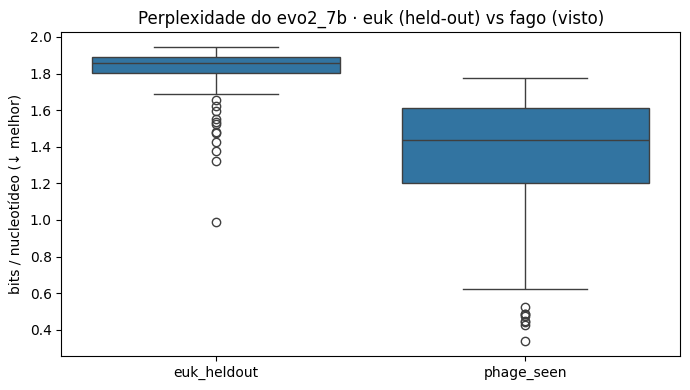

In [9]:
import matplotlib.pyplot as plt, seaborn as sns
plt.figure(figsize=(7,4))
sns.boxplot(data=perp, x="set_label", y="bits_nt")
plt.ylabel("bits / nucleotídeo (↓ melhor)"); plt.xlabel("")
plt.title(f"Perplexidade do {MODEL_NAME} · euk (held-out) vs fago (visto)")
plt.tight_layout(); plt.show()

## 4. Completação de fragmentos

Prompt = primeiros `PROMPT_BP` bp (o "contig"); alvo = `[PROMPT_BP : PROMPT_BP+GAP_BP]`. Comparamos três coisas no trecho-alvo:
- **bits/nt EVO2** (teacher-forced) vs **bits/nt Markov-k** (baseline de composição) — qualidade preditiva;
- **similaridade de k-mers** do trecho **gerado** (EVO2 vs Markov) contra o real — o "gera e compara".

In [10]:
import itertools
from collections import defaultdict, Counter

# ---- baseline Markov-k (ajustado nos prompts; Laplace) ----
def fit_markov(seqlist, k):
    trans = defaultdict(Counter)
    for s in seqlist:
        s = "".join(c for c in s.upper() if c in "ACGT")
        for i in range(len(s)-k): trans[s[i:i+k]][s[i+k]] += 1
    P={}
    for ctx,cnt in trans.items():
        tot=sum(cnt.values())+4; P[ctx]={b:(cnt.get(b,0)+1)/tot for b in "ACGT"}
    return P
def markov_gen(prefix,n,k,P):
    s=prefix[-k:]; out=[]
    for _ in range(n):
        pr=P.get(s[-k:]); 
        nxt=random.choice("ACGT") if pr is None else random.choices("ACGT",weights=[pr[b] for b in "ACGT"])[0]
        out.append(nxt); s+=nxt
    return "".join(out)
def markov_bits(prefix,gap,k,P):
    full=prefix[-k:]+gap; tot=0
    for i in range(k,len(full)):
        p=P.get(full[i-k:i],{}).get(full[i],0.25); tot+=-np.log2(max(p,1e-9))
    return tot/len(gap)

# ---- similaridade de k-mers ----
KMERS=["".join(p) for p in itertools.product("ACGT",repeat=KMER_K)]; KIDX={k:i for i,k in enumerate(KMERS)}
def kmer_vec(s):
    v=np.zeros(len(KMERS)); s=s.upper()
    for i in range(len(s)-KMER_K+1):
        j=KIDX.get(s[i:i+KMER_K]); 
        if j is not None: v[j]+=1
    n=np.linalg.norm(v); return v/n if n else v
def kmer_cos(a,b): return float(kmer_vec(a)@kmer_vec(b))

# ---- geração EVO2 (adapta ao retorno do .generate) ----
def evo2_gen(prefix,n):
    out=model.generate(prompt_seqs=[prefix], n_tokens=n, temperature=TEMPERATURE, top_k=TOP_K)
    g = getattr(out,"sequences",None)
    if g is None: g = out["sequences"] if isinstance(out,dict) else out
    g = g[0]
    if len(g)>=len(prefix) and g[:32]==prefix[:32]: g=g[len(prefix):]   # caso retorne prompt+gerado
    return g[:n]

Pmk = fit_markov([seqs[a][:PROMPT_BP] for a in subset.accession], MARKOV_ORDER)
def gc(s): s=s.upper(); return 100*(s.count("G")+s.count("C"))/max(1,len(s))

In [11]:
rows=[]
for r in tqdm(subset.itertuples(index=False), total=len(subset)):
    full = seqs[r.accession]
    prefix = full[:PROMPT_BP]; true_gap = full[PROMPT_BP:PROMPT_BP+GAP_BP]
    if len(true_gap) < GAP_BP: continue
    try:
        b_evo = bits_per_nt(prefix+true_gap, region=(PROMPT_BP, PROMPT_BP+GAP_BP))
        b_mk  = markov_bits(prefix, true_gap, MARKOV_ORDER, Pmk)
        g_evo = evo2_gen(prefix, GAP_BP)
        g_mk  = markov_gen(prefix, GAP_BP, MARKOV_ORDER, Pmk)
        rows.append(dict(accession=r.accession, set_label=r.set_label, baltimore=r.baltimore,
                         bits_evo=b_evo, bits_markov=b_mk,
                         kmer_evo=kmer_cos(g_evo,true_gap), kmer_markov=kmer_cos(g_mk,true_gap),
                         gc_true=gc(true_gap), gc_evo=gc(g_evo)))
    except Exception as e: print("falhou", r.accession, repr(e))
comp = pd.DataFrame(rows)
print("=== bits/nt no trecho-alvo (↓ melhor) ===")
print(comp.groupby("set_label")[["bits_evo","bits_markov"]].mean().round(3).to_string())
print("\n=== similaridade de k-mers do trecho gerado vs real (↑ melhor) ===")
print(comp.groupby("set_label")[["kmer_evo","kmer_markov"]].mean().round(3).to_string())

  0%|          | 0/200 [00:00<?, ?it/s]

Initializing inference params with max_seqlen=5120


/usr/local/lib/python3.12/dist-packages/vortex/model/engine.py:559: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  inference_params.state_dict[layer_idx] = state[..., L - 1].to(dtype=state_dtype)
  0%|          | 1/200 [00:24<1:22:10, 24.78s/it]

Prompt: "AGAGCAATCAAGCAACAGATTATAAACCTCCAGCACATGCTGAATGATCAAAACATTTTCAGAAATACTAATTTAGGTTTCTCCAACGTCTGGTCTGCTTATGGACTTTTATACCTTAGCAGATCTTCAACTCTATAACTATGCCATTTTTCTATTTTTCATTCTTTCATGCTTTTACTACTTATTATTTCATTAACTCTTGCCTCTAGCTTTAATCAGAATGTGCCTCTTCAGCAGTTCTCAAATAATCATTGAATTCATCATGATACACTGTCTTATCAAAAGTTTTTAGCTCTGATATCTCTTTATCTATGTGATTTATTGAGCTAAAGACTAAATCATTGATCTCTATATTTGTTGTGTTCTTGTATATACACTGATCATTTAAATAATCTAATTTAGCAGATATGTATGATCGTATCCTTAAAAGTACTTTCAACTTTTTGTTTTTGTTTTTCTCTGAAAAAACGGATTTTATCAGCATCTGCACATCGAAGGGCTCTATGAAATCCCCATGAGGAGTGGATAAGATTAAGAAATTTTCCAAGCTCGTAGCAACACCTAACAATATTTCTTCTTCTTTAGAATTCATAAAATGTCTTTGAACATATCCGCTTGCTCTCAGGGTCATTATAGATTTTATTAAACTCTCCATTCTATCATCTCTTTCAATAGAAAAATCAAAATGAGCACTAAGCATTTTTTGGACATCATACTCATTTCCCTTAATGCACAGCATCAAAAATTTCATGAGCTCACCTAGCAACAATGTATTTGCTGGTATCAAATAAGAACTCTTCTTTTTAGTAAGTCTCATTTGCCTAGAAACACTATCAAAAGTGCTGTGCTCATCTGTTATAGTGACAGGATTCAATTCTAACATGTCTGTTCCTAACTTAACATCAGAACCAGTTACTGTAAACCCATTTTGTCTCAGTATTTCTCTCACAGAATCTGTTATTTCTATATCACTTAATGATATAGTTTTATG

  1%|          | 2/200 [00:49<1:21:24, 24.67s/it]

...

Prompt: "GTGTCCTCTCCCCCTCCGGGGTTCAACCCGGGGTCGCCCGCACACGTACGCGGAAATCTAGTATAGGAGGCAGCTTGTGACTCTCGTCCACTTCGATTTGCGTCACCCCGGAGCCTCCGGACGCAAACCAGCAGCGGGGCGCATTGCTTGGGTCCCCACCGAGCGCAAGGTCGACGGGTCCATCGTGGTCCTCCCGACCCGCGTTTCGGTCACCCTGGACCCCCTCTCCTCCGCTCAGATTGAACCCGGAATCTACCTCTTCCACGAGGAAGTAGTCGGCGGCATCTCGGCTTACCGCGTTGTCCCGAACTCGCTGGAGGCCGACTACTCGTCTTTGGTGGCGATTGACCCGGCTACTTTGGACCCCGCGTCCCAGCCCGAGGCCGCGTGGTACGCCTTCGTTGAGACCCTGAATGCCGCCAATGCTGACATGCTGGCCTCCGCGCTCGCCTCTCAGCACTCCGCCGAACTCGCTCAGCTCTCCGCGACCGGCTCTCAGACCGCTGCCAGCGCATCCGCCCTCGCAGCGTCCAATTCGGCTGGTGCTGCTGCATCCTCCGCGACCCAAGCTGGAACGGCCCGTGATGGGGCTGTTTCGGCTCAGGGGTCGGCGGCTGGGTACGCTTCGGCGGCTTCGGGGTCGGCTGTTGCGGCTTCTGACTCCGCCTCCAGCGCAGCGGCCAGCGCTTCGAGCGCTTCCACCAGCGCCGGGACAGCCACTACGAAGGCCGCAGAGGCTACGGCAGCGGTTCTTGGCTTCTCGGTCGGTACGGTGTCCACGGTAGCCCCCTCGGAGGCCGCGTCTGCCACGATCACGGGTCCTGTCGGGTCTCGCGTACTCAATCTGTCGATCCCTCGGGGTGCGGTGCCAGTGTTCTCGGTCGCTGAAACCACTACCGGACCTGAGACCCCGGGCGCAACTGGCCTAAAGGGTGACAAGGGCGATAAGGGTGACCCGGGTGGTTGGACTACAGCTACCGATCTCGGTACG

100%|█████████▉| 199/200 [1:21:56<00:24, 24.71s/it]

Prompt: "CCACGACAAGGTGTTTTCTTACGTCACGCACAATTTTTGAGGATTTTTAAAAGGTGTCATGATTCAACTAGAGAGGAGAAACGATGAGTGGTTAAGAATCCGTACTATCAACAGAATAACGGGCGTTTACCCAGCGACCCGCCAAACCACTTAGGGGCAGTGTCAAGGGAGGTTTGGCGCAAAATCGTTCCGTTTTTAGAAAGCACAAATAAGGTTCAACGCATTGATACGTTTTTGGTTGAAACTTACTGCACGAATTATGAAATTTACAAACTCGCTTATGAGGATATTAAGCAAAATGGCATTCAGCAGGAAATTAAAAAGCCGATTCAAGCGCAAGGTAGTGGTGAAATTCTCGGCGAGCAGTCGCTTGGTTTTAAAAAGAATCCAGCAGTCGCCACAATGAAAGACGCCGTTGACACCTTGAATAGAATTGGTGTTCAGCTTGGTTTGACCCCTAAGGGACGTAAAGAGCTTATGGAAATTGCGAGTGAAGATACAAATAAGGTCTCAACAACGGAAATGTTGAAGGAATTTTTAGGGAAATAAAAAAAGAACGGCTTATGCCATTCCAAGGTATTCTTTCGATAAGTTCTGCTAAGTATATTATACGTGAATGTTTATAATTGCACAACACGTATATAAGTGTTATAATATATTTAGAGGTAACAATATGACGTTTTTGTACTCTCAAGATTTAAGTAACTGTACAACACAAAAACTCATGATATAGATTCGGCGTATGTTTTTGTACTCTCAAGATTTAAGTAACTGTACAACCCATCTTTACTTGTGTATTCAGGAACGTCAGTTTTTGTACTCTCAAGATTTAAGTAACAAAAAATAAAGCGTTATATCTAACGTTTTATTTTTTTTATTGAAAGGGGGTGATTAATAGTAAATGAAAACAAATTTAACAAAAACTCACGATATAGATGCAGCATATAAAGAATTTGATTTCACCGACATTGCAAAAAAATATCAAGACGAT

100%|██████████| 200/200 [1:22:21<00:00, 24.71s/it]

Prompt: "ATGAAGTGTATATTATTTAAATGGGTACTGTGCCTGTTACTGGGTTTTTCTTCGGTATCCTATTCCCGGGAGTTTACGATAGACTTTTCGACCCAACAAAGTTATGTCTCTTCGTTAAATAGTATACGGACAGAGATATCGACCCCTCTTGAACATATATCTCAGGGGACCACATCGGTGTCTGTTATTAACCACACCCCACCGGGCAGTTATTTTGCTGTGGATATACGAGGGCTTGATGTCTATCAGGCGCGTTTTGACCATCTTCGTCTGATTATTGAGCAAAATAATTTATATGTGGCCGGGTTCGTTAATACGGCAACAAATACTTTCTACCGTTTTTCAGATTTTACACATATATCAGTGCCCGGTGTGACAACGGTTTCCATGACAACGGACAGCAGTTATACCACTCTGCAACGTGTCGCAGCGCTGGAACGTTCCGGAATGCAAATCAGTCGTCACTCACTGGTTTCATCATATCTGGCGTTAATGGAGTTCAGTGGTAATACAATGACCAGAGATGCATCCAGAGCAGTTCTGCGTTTTGTCACTGTCACAGCAGAAGCCTTACGCTTCAGGCAGATACAGAGAGAATTTCGTCAGGCACTGTCTGAAACTGCTCCTGTGTATACGATGACGCCGGGAGACGTGGACCTCACTCTGAACTGGGGGCGAATCAGCAATGTGCTTCCGGAGTATCGGGGAGAGGATGGTGTCAGAGTGGGGAGAATATCCTTTAATAATATATCAGCGATACTGGGGACTGTGGCCGTTATACTGAATTGCCATCATCAGGGGGCGCGTTCTGTTCGCGCCGTGAATGAAGAGAGTCAACCAGAATGTCAGATAACTGGCGACAGGCCTGTTATAAAAATAAACAATACATTATGGGAAAGTAATACAGCTGCAGCGTTTCTGAACAGAAAGTCACAGTTTTTATATACAACGGGTAAATAAAGGAGTTAAGCATGAAGAAGATGTTTATGGC

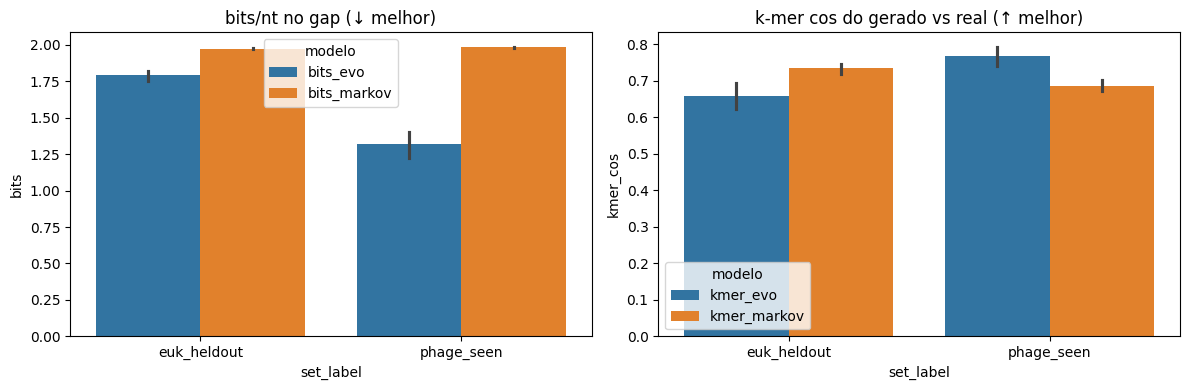

In [12]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
comp_m=comp.melt("set_label", ["bits_evo","bits_markov"], var_name="modelo", value_name="bits")
sns.barplot(data=comp_m, x="set_label", y="bits", hue="modelo", ax=ax[0]); ax[0].set_title("bits/nt no gap (↓ melhor)")
comp_k=comp.melt("set_label", ["kmer_evo","kmer_markov"], var_name="modelo", value_name="kmer_cos")
sns.barplot(data=comp_k, x="set_label", y="kmer_cos", hue="modelo", ax=ax[1]); ax[1].set_title("k-mer cos do gerado vs real (↑ melhor)")
plt.tight_layout(); plt.show()

## 5. Caveats (leakage e geração)

- **Leakage:** vírus de eucariotos são held-out **por construção** do OpenGenome2 (Evo 2 excluiu vírus de eucariotos do treino); fagos foram **incluídos**. O contraste euk×fago é o controle de "visto × não visto". Verificação adicional contra a lista exata do OpenGenome2 é um refinamento futuro.
- **EVO2 é autoregressivo** (causal): a "lacuna" é preenchida a partir do **contexto a montante** apenas (não usa o flanco 3′). É o cenário realista de **estender** um contig 5′→3′.
- **Geração longa** pode degradar/repetir — reportamos honestamente (benchmark do modelo "como está").
- `temperature`/`top_k` afetam o resultado; valores pré-registrados no CONFIG.

## Interpretação
- **Perplexidade menor em fago que em euk** confirmaria o efeito de treino (visto × não visto) e calibra o quanto o EVO2 "conhece" sequência viral fora do seu domínio.
- **EVO2 < Markov em bits/nt** e **k-mer EVO2 > Markov** indicam que o modelo captura estrutura além de composição local ao completar fragmentos — sustentando seu uso para estender contigs virais em metagenômica.
- Junto aos eixos de classificação e features, fecha o benchmark de capacidades do `evo2_7b` para genômica viral.